# Apache Spark + PySpark
### Цель работы
* изучить операции загрузки и выгрузки данных в HDFS,
* ознакомиться с базовыми операциями Apache Spark в spark-shell,
* создать проект по обработке данных в IDE,
* отладить анализ данных велопарковок на локальном компьютере,
* запустить анализ данных велопарковок на сервере.

## Установка Spark

In [2]:
!wget -q http://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

In [3]:
!tar xf spark-3.5.1-bin-hadoop3.tgz

In [4]:
!pip install -q findspark

In [5]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark

In [10]:
sc = spark.sparkContext

 ## Загрузка файлов

In [6]:
from google.colab import files
files.upload()

Saving list_of_countries_sorted_gini.txt to list_of_countries_sorted_gini.txt
Saving nyctaxi.csv to nyctaxi.csv
Saving nycTaxiFares.gz to nycTaxiFares.gz
Saving nycTaxiRides.gz to nycTaxiRides.gz
Saving posts_sample.xml to posts_sample.xml
Saving programming-languages.csv to programming-languages.csv
Saving stations.csv to stations.csv
Saving trips.csv to trips.csv
Saving warandsociety.txt to warandsociety.txt


In [7]:
!ls -lah

total 709M
drwxr-xr-x  1 root root 4.0K Mar  3 11:20 .
drwxr-xr-x  1 root root 4.0K Mar  3 10:41 ..
drwxr-xr-x  4 root root 4.0K Jan 16 14:24 .config
-rw-r--r--  1 root root  394 Mar  3 11:20 list_of_countries_sorted_gini.txt
-rw-r--r--  1 root root  76M Mar  3 11:20 nyctaxi.csv
-rw-r--r--  1 root root  19M Mar  3 11:20 nycTaxiFares.gz
-rw-r--r--  1 root root  81M Mar  3 11:20 nycTaxiRides.gz
-rw-r--r--  1 root root  71M Mar  3 11:20 posts_sample.xml
-rw-r--r--  1 root root  40K Mar  3 11:20 programming-languages.csv
drwxr-xr-x  1 root root 4.0K Jan 16 14:24 sample_data
drwxr-xr-x 13 1000 1000 4.0K Feb 15  2024 spark-3.5.1-bin-hadoop3
-rw-r--r--  1 root root 382M Feb 15  2024 spark-3.5.1-bin-hadoop3.tgz
-rw-r--r--  1 root root 5.6K Mar  3 11:20 stations.csv
-rw-r--r--  1 root root  77M Mar  3 11:20 trips.csv
-rw-r--r--  1 root root 5.1M Mar  3 11:20 warandsociety.txt


## Создание Resilient Distributed Dataset

In [13]:
warandpeace = sc.textFile("warandsociety.txt")
print(f"Количество строк: {warandpeace.count()}")

Количество строк: 12851


In [14]:
nilFile = sc.textFile("nil")
print(f"Читаем несуществующий файл: {nilFile.count()}")

Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.hadoop.mapred.InvalidInputException: Input path does not exist: file:/content/nil
	at org.apache.hadoop.mapred.FileInputFormat.singleThreadedListStatus(FileInputFormat.java:304)
	at org.apache.hadoop.mapred.FileInputFormat.listStatus(FileInputFormat.java:244)
	at org.apache.hadoop.mapred.FileInputFormat.getSplits(FileInputFormat.java:332)
	at org.apache.spark.rdd.HadoopRDD.getPartitions(HadoopRDD.scala:208)
	at org.apache.spark.rdd.RDD.$anonfun$partitions$2(RDD.scala:294)
	at scala.Option.getOrElse(Option.scala:189)
	at org.apache.spark.rdd.RDD.partitions(RDD.scala:290)
	at org.apache.spark.rdd.MapPartitionsRDD.getPartitions(MapPartitionsRDD.scala:49)
	at org.apache.spark.rdd.RDD.$anonfun$partitions$2(RDD.scala:294)
	at scala.Option.getOrElse(Option.scala:189)
	at org.apache.spark.rdd.RDD.partitions(RDD.scala:290)
	at org.apache.spark.api.python.PythonRDD.getPartitions(P

In [16]:
print(f"Первые 10 строк файла warandsociety.txt: {warandpeace.take(10)}")
print(f"Количество разделов: {warandpeace.getNumPartitions()}")

Первые 10 строк файла warandsociety.txt: ['Лев Николаевич Толстой', 'Война и мир. Книга 1', '', 'Война и мир – 1', '', ' ', ' http://www.lib.ru', '', 'Аннотация ', '']
Количество разделов: 2


## Обработка текста

In [17]:
linesWithWar = warandpeace.filter(lambda x: "война" in x)
print(f"Строки с 'война': {linesWithWar.collect()}")

Строки с 'война': ["– Еh bien, mon prince. Genes et Lucques ne sont plus que des apanages, des поместья, de la famille Buonaparte. Non, je vous previens, que si vous ne me dites pas, que nous avons la guerre, si vous vous permettez encore de pallier toutes les infamies, toutes les atrocites de cet Antichrist (ma parole, j'y crois) – je ne vous connais plus, vous n'etes plus mon ami, vous n'etes plus мой верный раб, comme vous dites. [Ну, что, князь, Генуа и Лукка стали не больше, как поместьями фамилии Бонапарте. Нет, я вас предупреждаю, если вы мне не скажете, что у нас война, если вы еще позволите себе защищать все гадости, все ужасы этого Антихриста (право, я верю, что он Антихрист) – я вас больше не знаю, вы уж не друг мой, вы уж не мой верный раб, как вы говорите.] Ну, здравствуйте, здравствуйте. Je vois que je vous fais peur, [Я вижу, что я вас пугаю,] садитесь и рассказывайте.", "– Vous savez, mon mari m'abandonne, – продолжала она тем же тоном, обращаясь к генералу, – il va se 

In [18]:
def time(f):
    import time
    t = time.process_time()
    f()
    print(f"Elapsed time: {int((time.process_time() - t)*1e9)} ns")

linesWithWar.cache()
time(lambda: linesWithWar.count())
time(lambda: linesWithWar.count())

Elapsed time: 4501125 ns
Elapsed time: 4396105 ns


In [25]:
wordCounts = linesWithWar.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)
wordCounts.saveAsTextFile("warandpeace_histogram")
!head -n 20 /content/warandpeace_histogram/part-*

==> /content/warandpeace_histogram/part-00000 <==
('Еh', 1)
('prince.', 1)
('et', 4)
('sont', 1)
('plus', 3)
('des', 2)
('la', 6)
('Buonaparte.', 1)
('Non,', 2)
('vous', 10)
('me', 1)
('nous', 1)
('guerre,', 2)
('permettez', 1)
('encore', 1)
('toutes', 2)
('les', 3)
('infamies,', 1)
('Antichrist', 1)
('(ma', 1)

==> /content/warandpeace_histogram/part-00001 <==
('–', 92)
('bien,', 1)
('mon', 6)
('Genes', 1)
('Lucques', 1)
('ne', 4)
('que', 9)
('apanages,', 1)
('поместья,', 1)
('de', 13)
('famille', 1)
('je', 5)
('previens,', 1)
('si', 2)
('dites', 1)
('pas,', 1)
('avons', 1)
('pallier', 1)
('atrocites', 1)
('cet', 1)


In [34]:
import re

# Пример написания регулярных выражений
p = re.compile(r'\w+')
letters = p.findall("a b c")
print(letters)

# Упражнение. Улучшите процедуру, убирая из слов лишние символы и трансформируя все слова в нижний регистр.
wordCountsRe = (linesWithWar.flatMap(lambda line: re.findall(r'\w+', line.lower()))
    .map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b))
wordCountsRe.saveAsTextFile("warandpeace_histogram_re")
!head -n 20 /content/warandpeace_histogram_re/part-*

['a', 'b', 'c']
==> /content/warandpeace_histogram_re/part-00000 <==
('genes', 1)
('et', 4)
('sont', 1)
('plus', 5)
('des', 2)
('поместья', 1)
('la', 7)
('non', 2)
('vous', 11)
('me', 1)
('pas', 1)
('nous', 1)
('permettez', 1)
('encore', 1)
('toutes', 2)
('les', 3)
('infamies', 1)
('antichrist', 1)
('ma', 1)
('parole', 1)

==> /content/warandpeace_histogram_re/part-00001 <==
('еh', 1)
('bien', 1)
('mon', 6)
('prince', 2)
('lucques', 1)
('ne', 4)
('que', 9)
('apanages', 1)
('de', 14)
('famille', 1)
('buonaparte', 1)
('je', 7)
('previens', 1)
('si', 2)
('dites', 3)
('avons', 1)
('guerre', 4)
('pallier', 1)
('atrocites', 1)
('cet', 1)


## Операции с множествами

In [35]:
a = sc.parallelize([1,2,3,4])
b = sc.parallelize([3,4,6,7])

print(f"Объединение: {a.union(b).collect()}")
print(f"Объединение distinct: {a.union(b).distinct().collect()}")
print(f"Пересечение: {a.intersection(b).collect()}")
print(f"Разность: {a.subtract(b).collect()}")

Объединение: [1, 2, 3, 4, 3, 4, 6, 7]
Объединение distinct: [4, 1, 2, 6, 3, 7]
Пересечение: [4, 3]
Разность: [1, 2]


*Упражнение. Найдите в исходном коде Spark определение функции distinct. Объясните почему реализация этой операции действительно убирает дубликаты.*

distinct([numPartitions])) - return a new dataset that contains the distinct elements of the source dataset (dозвращает новый набор данных, содержащий уникальные элементы исходного набора данных).

## Общие переменные

### Широковещательные переменные

In [36]:
broadcastVar = sc.broadcast([1,2,3])
print(f"Broadcast значение: {broadcastVar.value}")

Broadcast значение: [1, 2, 3]


### Аккумулирующие переменные

In [37]:
accum = sc.accumulator(0)
sc.parallelize([1,2,3,4]).foreach(lambda x: accum.add(x))
print(f"Accumulator значение: {accum.value}")

Accumulator значение: 10


### Пары ключ-значение

In [38]:
pair = ('a', 'b')
print(f"Первое значение: {pair[0]}")
print(f"Второе значение: {pair[1]}")

Первое значение: a
Второе значение: b


## Топ-10 популярных номеров такси
Проанализируем данные о поездках такси в Нью-Йорке и найдём 10 номеров такси, которые совершили наибольшее количество поездок.
Создайте RDD на основе загруженных данных nyctaxi.csv и выведите первые 5 строк из данной таблицы.

In [40]:
taxi = sc.textFile("nyctaxi.csv")
for t in taxi.take(5):
    print(t)

"_id","_rev","dropoff_datetime","dropoff_latitude","dropoff_longitude","hack_license","medallion","passenger_count","pickup_datetime","pickup_latitude","pickup_longitude","rate_code","store_and_fwd_flag","trip_distance","trip_time_in_secs","vendor_id"
"29b3f4a30dea6688d4c289c9672cb996","1-ddfdec8050c7ef4dc694eeeda6c4625e","2013-01-11 22:03:00",+4.07033460000000E+001,-7.40144200000000E+001,"A93D1F7F8998FFB75EEF477EB6077516","68BC16A99E915E44ADA7E639B4DD5F59",2,"2013-01-11 21:48:00",+4.06760670000000E+001,-7.39810790000000E+001,1,,+4.08000000000000E+000,900,"VTS"
"2a80cfaa425dcec0861e02ae44354500","1-b72234b58a7b0018a1ec5d2ea0797e32","2013-01-11 04:28:00",+4.08190960000000E+001,-7.39467470000000E+001,"64CE1B03FDE343BB8DFB512123A525A4","60150AA39B2F654ED6F0C3AF8174A48A",1,"2013-01-11 04:07:00",+4.07280540000000E+001,-7.40020370000000E+001,1,,+8.53000000000000E+000,1260,"VTS"
"29b3f4a30dea6688d4c289c96758d87e","1-387ec30eac5abda89d2abefdf947b2c1","2013-01-11 22:02:00",+4.07277180000000E+00

Обратите внимание, что первая строка является заголовком. Её как правило нужно будет отфильтровать. Одним из эффективных способов является следующий:

In [46]:
import itertools
taxi.mapPartitionsWithIndex(lambda idx, it:  itertools.islice(it,1,None) if (idx==0) else it)
print(taxi.take(10))

['"_id","_rev","dropoff_datetime","dropoff_latitude","dropoff_longitude","hack_license","medallion","passenger_count","pickup_datetime","pickup_latitude","pickup_longitude","rate_code","store_and_fwd_flag","trip_distance","trip_time_in_secs","vendor_id"', '"29b3f4a30dea6688d4c289c9672cb996","1-ddfdec8050c7ef4dc694eeeda6c4625e","2013-01-11 22:03:00",+4.07033460000000E+001,-7.40144200000000E+001,"A93D1F7F8998FFB75EEF477EB6077516","68BC16A99E915E44ADA7E639B4DD5F59",2,"2013-01-11 21:48:00",+4.06760670000000E+001,-7.39810790000000E+001,1,,+4.08000000000000E+000,900,"VTS"', '"2a80cfaa425dcec0861e02ae44354500","1-b72234b58a7b0018a1ec5d2ea0797e32","2013-01-11 04:28:00",+4.08190960000000E+001,-7.39467470000000E+001,"64CE1B03FDE343BB8DFB512123A525A4","60150AA39B2F654ED6F0C3AF8174A48A",1,"2013-01-11 04:07:00",+4.07280540000000E+001,-7.40020370000000E+001,1,,+8.53000000000000E+000,1260,"VTS"', '"29b3f4a30dea6688d4c289c96758d87e","1-387ec30eac5abda89d2abefdf947b2c1","2013-01-11 22:02:00",+4.0727718

Для разбора значений потребуется создать RDD, где каждая строка разбита на массив подстрок. Используйте запятую в качестве разделителя. Наберите:

In [47]:
taxiParse = taxi.map(lambda line: line.split(","))
print(taxiParse.take(10))

[['"_id"', '"_rev"', '"dropoff_datetime"', '"dropoff_latitude"', '"dropoff_longitude"', '"hack_license"', '"medallion"', '"passenger_count"', '"pickup_datetime"', '"pickup_latitude"', '"pickup_longitude"', '"rate_code"', '"store_and_fwd_flag"', '"trip_distance"', '"trip_time_in_secs"', '"vendor_id"'], ['"29b3f4a30dea6688d4c289c9672cb996"', '"1-ddfdec8050c7ef4dc694eeeda6c4625e"', '"2013-01-11 22:03:00"', '+4.07033460000000E+001', '-7.40144200000000E+001', '"A93D1F7F8998FFB75EEF477EB6077516"', '"68BC16A99E915E44ADA7E639B4DD5F59"', '2', '"2013-01-11 21:48:00"', '+4.06760670000000E+001', '-7.39810790000000E+001', '1', '', '+4.08000000000000E+000', '900', '"VTS"'], ['"2a80cfaa425dcec0861e02ae44354500"', '"1-b72234b58a7b0018a1ec5d2ea0797e32"', '"2013-01-11 04:28:00"', '+4.08190960000000E+001', '-7.39467470000000E+001', '"64CE1B03FDE343BB8DFB512123A525A4"', '"60150AA39B2F654ED6F0C3AF8174A48A"', '1', '"2013-01-11 04:07:00"', '+4.07280540000000E+001', '-7.40020370000000E+001', '1', '', '+8.5300

Теперь преобразуем массив строк в массив пар ключ-значение, где ключом будет служить номер такси (6 колонка), а значением единица.

In [48]:
taxiMedKey = taxiParse.map(lambda row: (row[6], 1))
print(taxiMedKey.take(10))

[('"medallion"', 1), ('"68BC16A99E915E44ADA7E639B4DD5F59"', 1), ('"60150AA39B2F654ED6F0C3AF8174A48A"', 1), ('"6F907BC9A85B7034C8418A24A0A75489"', 1), ('"1AFFD48CC07161DA651625B562FE4D06"', 1), ('"8BF138EA0CF6FF83587993BECA6D6D59"', 1), ('"23A8ED0AAA1936A28C652B80903B42FB"', 1), ('"42BC02EC8FC9719B5B8075C3029B9EE9"', 1), ('"EB49CE1B3661EF6100CF9EA1B860932E"', 1), ('"DDE6F0B0832FA5CCE8491924E360FB45"', 1)]


Следом мы можем найти количество поездок каждого номера такси и выведем полученные результаты в отсортированном виде:

In [49]:
taxiMedCounts = taxiMedKey.reduceByKey(lambda v1, v2: v1+v2)
top10 = taxiMedCounts.map(lambda x: x[::-1]).top(10)
for x in top10:
    print(x[::-1])

('"AB44AD9A03B7CFAF3925103BDCC0AF23"', 44)
('"71CACFBADF9568AAE88A843DB511D172"', 41)
('"6483B9BFCB216EC88986EA3AB13064E7"', 41)
('"4C73459B430339981D78795300433438"', 41)
('"67E71D24AF704D814A0A825005ADA72E"', 40)
('"02E5A4136FD0A775A023A005A4EABC62"', 40)
('"9DFBCD218E7116F34C044F0680A0FB8A"', 39)
('"8DEB70907D00AA1D7FF5E2683240549B"', 39)
('"7989C2AB3F345F4AB54D3CF1E0480D67"', 39)
('"6C9F67DF658DC5636F9E7752F203F70A"', 39)


Примечание. Нотация _.swap является объявлением анонимной функции от одного аргумента, аналог записи `x => x.swap`.

Являются ли обе map операции распределёнными? Да.

Найдите в документации Spark в классах RDD или PairRDDFunctions метод top.

RDD.top(num, key=None) - get the top N elements from an RDD. This method should only be used if the resulting array is expected to be small, as all the data is loaded into the driver’s memory. It returns the list sorted in descending order. (Этот метод позволяет получить N верхних элементов из RDD. Его следует использовать только в том случае, если ожидается небольшой размер результирующего массива, поскольку все данные загружаются в память драйвера. Он возвращает список, отсортированный в порядке убывания.)

Вы также можете сгруппировать все описанные выше трансформации, преобразующие исходные данные в одну цепочку:

In [50]:
taxiCounts = taxi.map(lambda line: line.split(",")).map(lambda row: (row[6],1)).reduceByKey(lambda a,b: a + b)
top10_2 = taxiCounts.map(lambda x: x[::-1]).top(10)
for x in top10_2:
    print(x[::-1])

('"AB44AD9A03B7CFAF3925103BDCC0AF23"', 44)
('"71CACFBADF9568AAE88A843DB511D172"', 41)
('"6483B9BFCB216EC88986EA3AB13064E7"', 41)
('"4C73459B430339981D78795300433438"', 41)
('"67E71D24AF704D814A0A825005ADA72E"', 40)
('"02E5A4136FD0A775A023A005A4EABC62"', 40)
('"9DFBCD218E7116F34C044F0680A0FB8A"', 39)
('"8DEB70907D00AA1D7FF5E2683240549B"', 39)
('"7989C2AB3F345F4AB54D3CF1E0480D67"', 39)
('"6C9F67DF658DC5636F9E7752F203F70A"', 39)


Примечание. Нотация `_ + _` является объявлением анонимной функции от двух аргументов, аналог более многословной записи `(a,b) => a + b`.

Попробуйте найти общее количество номеров такси несколько раз, предварительно объявив RDD taxiCounts как сохраняемую в кэше. Сравните время, которое трансформации выполняются первый раз и второй. Чем больше данные, тем существеннее разница.

In [53]:
taxiCounts.cache()
time(lambda: taxiCounts.count())
time(lambda: taxiCounts.count())

Elapsed time: 3550624 ns
Elapsed time: 5287133 ns


## Решите следующие задачи для данных велопарковок Сан-Франциско (trips.csv, stations.csv):

In [59]:
from pyspark.sql import functions as F

In [56]:
stations_df = spark.read.csv('stations.csv', header=True, inferSchema=True)
trips_df = spark.read.csv('trips.csv', header=True, inferSchema=True)

stations_df.dropna().show(3)
trips_df.dropna().show(3)

+---+--------------------+---------+-------------------+----------+--------+-----------------+
| id|                name|      lat|               long|dock_count|    city|installation_date|
+---+--------------------+---------+-------------------+----------+--------+-----------------+
|  2|San Jose Diridon ...|37.329732|-121.90178200000001|        27|San Jose|         8/6/2013|
|  3|San Jose Civic Ce...|37.330698|        -121.888979|        15|San Jose|         8/5/2013|
|  4|Santa Clara at Al...|37.333988|        -121.894902|        11|San Jose|         8/6/2013|
+---+--------------------+---------+-------------------+----------+--------+-----------------+
only showing top 3 rows

+----+--------+---------------+--------------------+----------------+---------------+--------------------+--------------+-------+-----------------+--------+
|  id|duration|     start_date|  start_station_name|start_station_id|       end_date|    end_station_name|end_station_id|bike_id|subscription_type|zip_co

In [58]:
stations_df.printSchema()
trips_df.printSchema()

print("Stations count:", stations_df.count())
print("Trips count:", trips_df.count())

root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- dock_count: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- installation_date: string (nullable = true)

root
 |-- id: integer (nullable = true)
 |-- duration: integer (nullable = true)
 |-- start_date: string (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- end_date: string (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_id: integer (nullable = true)
 |-- bike_id: integer (nullable = true)
 |-- subscription_type: string (nullable = true)
 |-- zip_code: string (nullable = true)

Stations count: 70
Trips count: 669959


### 1. Найти велосипед с максимальным временем пробега.


In [67]:
bike_total_duration = trips_df.groupBy('bike_id').agg(F.sum('duration').alias('total_duration'))
max_bike = bike_total_duration.orderBy(F.col('total_duration').desc()).first()
max_bike

Row(bike_id=535, total_duration=18611693)

### 2. Найти наибольшее геодезическое расстояние между станциями.


In [70]:
s1 = stations_df.select(
    F.col("id").alias("id1"),
    F.col("name").alias("name1"),
    F.col("lat").alias("lat1"),
    F.col("long").alias("long1"),
)
s2 = stations_df.select(
    F.col("id").alias("id2"),
    F.col("name").alias("name2"),
    F.col("lat").alias("lat2"),
    F.col("long").alias("long2"),
)

pairs = s1.crossJoin(s2).where(F.col("id1") < F.col("id2"))
pairs.show(3)

+---+--------------------+---------+-------------------+---+--------------------+---------+-----------+
|id1|               name1|     lat1|              long1|id2|               name2|     lat2|      long2|
+---+--------------------+---------+-------------------+---+--------------------+---------+-----------+
|  2|San Jose Diridon ...|37.329732|-121.90178200000001|  3|San Jose Civic Ce...|37.330698|-121.888979|
|  2|San Jose Diridon ...|37.329732|-121.90178200000001|  4|Santa Clara at Al...|37.333988|-121.894902|
|  2|San Jose Diridon ...|37.329732|-121.90178200000001|  5|    Adobe on Almaden|37.331415|  -121.8932|
+---+--------------------+---------+-------------------+---+--------------------+---------+-----------+
only showing top 3 rows



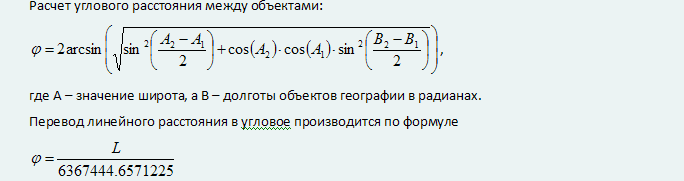

In [75]:
lat1 = F.radians("lat1")
lat2 = F.radians("lat2")
long1 = F.radians("long1")
long2 = F.radians("long2")
a = (F.pow(F.sin((lat2 - lat1)/2), 2) + F.cos(lat1) * F.cos(lat2) * F.pow(F.sin((long2 - long1)/2), 2))
dist = 2 * F.asin(F.sqrt(a))
dist_km = dist * 6367444.6571225
farthest = (pairs.withColumn("dist_km", dist_km).orderBy(F.col("dist_km").desc()).first())
farthest

Row(id1=16, name1='SJSU - San Salvador at 9th', lat1=37.333954999999996, long1=-121.877349, id2=60, name2='Embarcadero at Sansome', lat2=37.80477, long2=-122.40323400000001, dist_km=69881.85654001207)

### 3. Найти путь велосипеда с максимальным временем пробега через станции.


In [77]:
max_bike_id = max_bike['bike_id']
bike_trips = trips_df.filter(F.col('bike_id') == max_bike_id).orderBy('start_date') \
    .select('start_station_name', 'end_station_name', 'start_date', 'duration')
bike_trips.show(20)

+--------------------+--------------------+---------------+--------+
|  start_station_name|    end_station_name|     start_date|duration|
+--------------------+--------------------+---------------+--------+
|Mechanics Plaza (...|Embarcadero at Sa...| 1/1/2014 13:42|    3289|
|Embarcadero at Sa...|       Market at 4th| 1/1/2014 18:51|    1286|
|       Market at 4th|South Van Ness at...| 1/1/2014 19:48|     795|
|      Market at 10th|  Powell Street BART|1/10/2014 20:13|     235|
|Embarcadero at Fo...|San Francisco Cal...| 1/10/2014 8:09|     596|
|San Francisco Cal...|Temporary Transba...| 1/10/2014 8:21|     600|
|Temporary Transba...|      Market at 10th| 1/10/2014 9:19|     802|
|  Powell Street BART|      Market at 10th|1/11/2014 19:06|     336|
|      Market at 10th|       Market at 4th|1/12/2014 12:21|     480|
|       Market at 4th|San Francisco Cal...|1/12/2014 17:36|    1309|
|    Davis at Jackson|     Beale at Market|1/13/2014 17:04|     132|
|     Beale at Market|    Davis at

### 4. Найти количество велосипедов в системе.

In [78]:
trips_df.select("bike_id").distinct().count()

700

### 5. Найти пользователей потративших на поездки более 3 часов.

In [81]:
users_over3 = trips_df.groupBy('zip_code').agg(F.sum('duration').alias('total_duration')).filter(F.col("total_duration") > 3*3600)
users_over3.show(20)

+--------+--------------+
|zip_code|total_duration|
+--------+--------------+
|   94102|      19128021|
|   95134|        728023|
|   84606|         95145|
|   80305|        180906|
|   60070|         28919|
|   95519|         30303|
|   43085|         11670|
|   91910|         50488|
|   77339|         13713|
|   48063|         13755|
|   85022|         12682|
|    1090|         20391|
|    2136|         16010|
|   11722|         24331|
|   95138|        155295|
|   94610|       3630628|
|   94404|       3589350|
|   80301|        152189|
|   91326|         65885|
|   90742|         10965|
+--------+--------------+
only showing top 20 rows

